# Data Cleaning and Initial Exploration

## 1. Read Data Files



In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import seaborn as sns

Own_Funds_Original=pd.read_csv("SQ_Own_Funds.csv",encoding="latin1")
Balance_Sheet_Original=pd.read_csv("SQ_Balance_Sheet.csv",encoding="latin1")
Premiums_Original=pd.read_csv("SQ_Premiums_Claims_Expenses.csv",encoding="latin1")

In [ ]:
Own_Funds_Original.head()

,Reporting country,Reference period,Item code,Item name,Value,Undertaking type,Date of extraction (yyyymmdd),"Number of submissions (per reporting country, reference date and undertaking type)"
0,AUSTRIA,2016 Q3,R0500,Total available own funds to meet the SCR,856.112328,Life undertakings,20250930,7
1,AUSTRIA,2016 Q3,R0500,Total available own funds to meet the SCR,16353.071138,Non-Life undertakings,20250930,15
2,AUSTRIA,2016 Q3,R0500,Total available own funds to meet the SCR,15943.253781,Other undertakings,20250930,19
3,AUSTRIA,2016 Q3,R0510,Total available own funds to meet the MCR,856.112328,Life undertakings,20250930,7
4,AUSTRIA,2016 Q3,R0510,Total available own funds to meet the MCR,16316.286682,Non-Life undertakings,20250930,15


### Create Dictionary of Codes

In [ ]:
Balance_Sheet_Original['Item code'] = Balance_Sheet_Original['Item code'].astype(str) + '_BS'
Premiums_Original['Item code'] = Premiums_Original['Item code'].astype(str) + '_P'
Own_Funds_Original['Item code'] = Own_Funds_Original['Item code'].astype(str) + '_O'

In [ ]:
Codes = (
    pd.concat([
        Balance_Sheet_Original[['Item code', 'Item name']],
        Premiums_Original[['Item code', 'Item']].rename(columns={'Item': 'Item name'}),
        Own_Funds_Original[['Item code', 'Item name']]
    ])
    .drop_duplicates(subset=['Item code'])
    .reset_index(drop=True))

In [ ]:
Codes.tail(2)

,Item code,Item name
155,R0540 - C0040_O,EOF Tier 2
156,R0540 - C0050_O,EOF Tier 3


####Fix the Reference Period

In [ ]:
Balance_Sheet_Original['Year'] = Balance_Sheet_Original['Reference period'].str.extract(r'(\d{4})').astype(int)
Balance_Sheet_Original['Quarter'] = Balance_Sheet_Original['Reference period'].str.extract(r'(Q\d)')[0]
Balance_Sheet_Original['Date'] = pd.PeriodIndex(    Balance_Sheet_Original['Year'].astype(str) + Balance_Sheet_Original['Quarter'],freq='Q').to_timestamp()
Balance_Sheet_Original.drop(columns=['Year', 'Quarter'], inplace=True)

In [ ]:
Premiums_Original['Year'] = Premiums_Original['Reference period'].str.extract(r'(\d{4})').astype(int)
Premiums_Original['Quarter'] = Premiums_Original['Reference period'].str.extract(r'(Q\d)')[0]
Premiums_Original['Date'] = pd.PeriodIndex(Premiums_Original['Year'].astype(str) + Premiums_Original['Quarter'],freq='Q').to_timestamp()
Premiums_Original.drop(columns=['Year', 'Quarter'], inplace=True)

In [ ]:
Own_Funds_Original['Year'] = Own_Funds_Original['Reference period'].str.extract(r'(\d{4})').astype(int)
Own_Funds_Original['Quarter'] = Own_Funds_Original['Reference period'].str.extract(r'(Q\d)')[0]
Own_Funds_Original['Date'] = pd.PeriodIndex(Own_Funds_Original['Year'].astype(str) + Own_Funds_Original['Quarter'],freq='Q').to_timestamp()
Own_Funds_Original.drop(columns=['Year', 'Quarter'], inplace=True)

In [ ]:
Own_Funds_Original

,Reporting country,Reference period,Item code,Item name,Value,Undertaking type,Date of extraction (yyyymmdd),"Number of submissions (per reporting country, reference date and undertaking type)",Date
0,AUSTRIA,2016 Q3,R0500_O,Total available own funds to meet the SCR,856.112328,Life undertakings,20250930,7,2016-07-01
1,AUSTRIA,2016 Q3,R0500_O,Total available own funds to meet the SCR,16353.071138,Non-Life undertakings,20250930,15,2016-07-01
2,AUSTRIA,2016 Q3,R0500_O,Total available own funds to meet the SCR,15943.253781,Other undertakings,20250930,19,2016-07-01
3,AUSTRIA,2016 Q3,R0510_O,Total available own funds to meet the MCR,856.112328,Life undertakings,20250930,7,2016-07-01
4,AUSTRIA,2016 Q3,R0510_O,Total available own funds to meet the MCR,16316.286682,Non-Life undertakings,20250930,15,2016-07-01
...,...,...,...,...,...,...,...,...,...
66250,SWEDEN,2025 Q2,R0640_P75_O,Ratio of Eligible own funds to MCR (P75),6.988910,Other undertakings,20250930,14,2025-04-01
66251,SWEDEN,2025 Q2,R0640_P90_O,Ratio of Eligible own funds to MCR (P90),8.613950,All undertaking types,20250930,113,2025-04-01
66252,SWEDEN,2025 Q2,R0640_P90_O,Ratio of Eligible own funds to MCR (P90),5.434460,Life undertakings,20250930,14,2025-04-01
66253,SWEDEN,2025 Q2,R0640_P90_O,Ratio of Eligible own funds to MCR (P90),8.681020,Non-Life undertakings,20250930,85,2025-04-01


## 2. Restructure the data bases

1. Use only the columns we are interested

In [ ]:
Balance_Sheet = Balance_Sheet_Original[['Reporting country','Date', 'Value','Item code']]
Premiums = Premiums_Original[['Reporting country','Date', 'Value','Item code']]
Own_Funds = Own_Funds_Original[['Reporting country','Date', 'Value','Item code']]



2.   Long to Wide format



In [ ]:
Balance_Sheet_wide = (
    Balance_Sheet.pivot_table(
        index=['Reporting country', 'Date'],
        columns='Item code',
        values='Value',
        aggfunc='sum',           # ✅ sum duplicates
        fill_value=0             # optional: replace NaNs with 0
    )
    .reset_index()
)

Premiums_wide = (
    Premiums.pivot_table(
        index=['Reporting country', 'Date'],
        columns='Item code',
        values='Value',
        aggfunc='sum',           # ✅ sum duplicates
        fill_value=0
    )
    .reset_index()
)

Own_Funds_wide = (
    Own_Funds.pivot_table(
        index=['Reporting country', 'Date'],
        columns='Item code',
        values='Value',
        aggfunc='sum',           # ✅ sum duplicates
        fill_value=0
    )
    .reset_index()
)


In [ ]:
Balance_Sheet_wide.head(2)

Item code,Reporting country,Date,R0001_BS,R0010_BS,R0020_BS,R0030_BS,R0040_BS,R0050_BS,R0060_BS,R0070_BS,...,R0810_BS,R0820_BS,R0830_BS,R0840_BS,R0850_BS,R0860_BS,R0870_BS,R0880_BS,R0900_BS,R1000_BS
0,AUSTRIA,2016-07-01,0.0,0.0,0.0,0.0,1906.768025,49.408931,904.896925,102848.059472,...,566.429698,596.602407,675.716662,1901.797149,3537.720381,0.000000,3537.720381,618.188377,111158.596047,30248.404527
1,AUSTRIA,2016-10-01,0.0,0.0,0.0,0.0,1240.440968,48.256793,975.785244,102945.441183,...,586.810630,852.301742,493.989152,1691.547709,3384.804249,260.855371,3123.948878,418.481195,105145.325667,34262.491946


In [ ]:
Premiums_wide.head(2)

Item code,Reporting country,Date,R0101_P,R0110_P,R0120_P,R0130_P,R0140_P,R0200_P,R0201_P,R0210_P,...,R1701_P,R1710_P,R1720_P,R1800_P,R1900_P,R2500_P,R2510_P,R2600_P,Z0001_P,Z0002_P
0,AUSTRIA,2016-07-01,0.0,7014.674593,1227.558933,30.519672,2577.818515,5694.934683,0.0,6658.226021,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,AUSTRIA,2016-10-01,0.0,8820.385891,1614.834650,46.186761,3317.361617,7164.045685,0.0,8806.180214,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


3.   Exclude 'EEA' from the 'Countries' in Premiums



In [ ]:
Premiums_wide=Premiums_wide[Premiums_wide['Reporting country']!='EEA']
Own_Funds_wide=Own_Funds_wide[Own_Funds_wide['Reporting country']!='EEA']

## 3. Merge the Data Bases

In [ ]:
df = pd.merge(Balance_Sheet_wide, Premiums_wide, on=["Reporting country", "Date"], how="outer")
df = pd.merge(df, Own_Funds_wide, on=["Reporting country", "Date"], how="outer")
df.head(3)

Item code,Reporting country,Date,R0001_BS,R0010_BS,R0020_BS,R0030_BS,R0040_BS,R0050_BS,R0060_BS,R0070_BS,...,R0620_P25_O,R0620_P50_O,R0620_P75_O,R0620_P90_O,R0640_O,R0640_P10_O,R0640_P25_O,R0640_P50_O,R0640_P75_O,R0640_P90_O
0,AUSTRIA,2016-07-01,0.0,0.0,0.0,0.0,1906.768025,49.408931,904.896925,102848.059472,...,7.52010,9.64732,11.55703,13.46049,29.20316,13.38675,18.88067,25.71791,33.20640,39.99726
1,AUSTRIA,2016-10-01,0.0,0.0,0.0,0.0,1240.440968,48.256793,975.785244,102945.441183,...,8.55114,10.24471,12.08615,13.66983,33.52924,15.91609,22.11017,28.80159,36.44562,42.62757
2,AUSTRIA,2017-01-01,0.0,0.0,0.0,0.0,1096.443040,48.134599,918.344415,102288.682296,...,8.30067,10.27427,11.74052,14.39609,32.20706,16.74696,21.42416,27.99324,36.07590,42.66843


In [ ]:
print("Balance_Sheet shape:", Balance_Sheet_wide.shape)
print("Premiums shape:", Premiums_wide.shape)
print("Own_Funds shape:", Own_Funds_wide.shape)
print("df shape:", df.shape)

Balance_Sheet shape: (1079, 87)
Premiums shape: (1079, 52)
Own_Funds shape: (1079, 24)
df shape: (1079, 159)


## 4. Missing Values and format

1. Replace N/A with 0


In [ ]:
df = df.fillna(0)

2.   Make sure all columns except 'Reporting country' and 'Date' are float and round to 2 decimals.



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1079 entries, 0 to 1078
Columns: 159 entries, Reporting country to R0640_P90_O
dtypes: datetime64[ns](1), float64(157), object(1)
memory usage: 1.3+ MB


In [ ]:
df

Item code,Reporting country,Date,R0001_BS,R0010_BS,R0020_BS,R0030_BS,R0040_BS,R0050_BS,R0060_BS,R0070_BS,...,R0620_P25_O,R0620_P50_O,R0620_P75_O,R0620_P90_O,R0640_O,R0640_P10_O,R0640_P25_O,R0640_P50_O,R0640_P75_O,R0640_P90_O
0,AUSTRIA,2016-07-01,0.0,0.0,0.0,0.000000,1906.768025,49.408931,904.896925,102848.059472,...,7.52010,9.64732,11.55703,13.46049,29.20316,13.38675,18.88067,25.71791,33.20640,39.99726
1,AUSTRIA,2016-10-01,0.0,0.0,0.0,0.000000,1240.440968,48.256793,975.785244,102945.441183,...,8.55114,10.24471,12.08615,13.66983,33.52924,15.91609,22.11017,28.80159,36.44562,42.62757
2,AUSTRIA,2017-01-01,0.0,0.0,0.0,0.000000,1096.443040,48.134599,918.344415,102288.682296,...,8.30067,10.27427,11.74052,14.39609,32.20706,16.74696,21.42416,27.99324,36.07590,42.66843
3,AUSTRIA,2017-04-01,0.0,0.0,0.0,0.000000,1036.858955,47.654477,874.071136,103652.429316,...,8.42845,10.15729,11.73763,14.52526,33.56952,16.98614,21.98091,28.55037,36.41205,40.60989
4,AUSTRIA,2017-07-01,0.0,0.0,0.0,0.000000,1035.099143,47.136376,892.174582,104608.597045,...,8.54471,10.35783,11.90962,14.47787,34.01060,17.24452,22.66969,28.94775,37.88953,41.83012
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1074,SWEDEN,2024-04-01,0.0,0.0,0.0,0.255971,39.305836,37.209800,830.547269,147198.407775,...,6.34952,7.49844,9.32786,12.29437,26.54571,11.03007,15.92613,22.05167,28.00403,33.23887
1075,SWEDEN,2024-07-01,0.0,0.0,0.0,0.300532,33.398470,33.637802,825.054867,150001.674758,...,6.41708,7.62682,9.27234,11.60056,26.65424,11.56036,16.36059,22.11700,28.14620,33.56828
1076,SWEDEN,2024-10-01,0.0,0.0,0.0,0.000000,35.017581,41.083958,827.626389,146952.384948,...,6.30095,7.22668,8.68717,11.32406,26.23922,11.22487,15.83877,22.19289,27.17214,33.91020
1077,SWEDEN,2025-01-01,0.0,0.0,0.0,0.000000,51.763969,59.701292,879.182643,152333.967558,...,6.31592,7.25802,8.73743,10.68130,25.86379,10.95717,15.85985,21.74968,26.87912,31.02951


In [ ]:
num_cols = df.columns.difference(['Reporting country', 'Date'])
df[num_cols] = df[num_cols].astype(float)
df[num_cols] = df[num_cols].round(2)

In [ ]:
num_cols = df.columns.difference(['Reporting country', 'Date'])

for col in num_cols:
    # mask of values that can't be converted
    mask = pd.to_numeric(df[col], errors='coerce').isna() & df[col].notna()
    if mask.any():
        print(f"Column: {col}")
        print(df.loc[mask, col])


In [ ]:
df.tail(4)

Item code,Reporting country,Date,R0001_BS,R0010_BS,R0020_BS,R0030_BS,R0040_BS,R0050_BS,R0060_BS,R0070_BS,...,R0620_P25_O,R0620_P50_O,R0620_P75_O,R0620_P90_O,R0640_O,R0640_P10_O,R0640_P25_O,R0640_P50_O,R0640_P75_O,R0640_P90_O
1075,SWEDEN,2024-07-01,0.0,0.0,0.0,0.3,33.40,33.64,825.05,150001.67,...,6.42,7.63,9.27,11.60,26.65,11.56,16.36,22.12,28.15,33.57
1076,SWEDEN,2024-10-01,0.0,0.0,0.0,0.0,35.02,41.08,827.63,146952.38,...,6.30,7.23,8.69,11.32,26.24,11.22,15.84,22.19,27.17,33.91
1077,SWEDEN,2025-01-01,0.0,0.0,0.0,0.0,51.76,59.70,879.18,152333.97,...,6.32,7.26,8.74,10.68,25.86,10.96,15.86,21.75,26.88,31.03
1078,SWEDEN,2025-04-01,0.0,0.0,0.0,0.0,49.89,54.37,852.81,149996.78,...,6.33,7.52,8.71,11.13,25.60,11.69,16.42,21.89,26.82,31.07


## 5. Check for duplicates

In [ ]:
duplicates = df[df.duplicated(subset=['Reporting country', 'Date'], keep=False)]
print(duplicates)
print(f"\nTotal duplicated rows: {len(duplicates)}")


Empty DataFrame
Columns: [Reporting country, Date, R0001_BS, R0010_BS, R0020_BS, R0030_BS, R0040_BS, R0050_BS, R0060_BS, R0070_BS, R0080_BS, R0090_BS, R0100_BS, R0110_BS, R0120_BS, R0130_BS, R0140_BS, R0150_BS, R0160_BS, R0170_BS, R0180_BS, R0190_BS, R0200_BS, R0210_BS, R0220_BS, R0230_BS, R0240_BS, R0250_BS, R0260_BS, R0270_BS, R0280_BS, R0290_BS, R0300_BS, R0310_BS, R0320_BS, R0330_BS, R0340_BS, R0350_BS, R0360_BS, R0370_BS, R0380_BS, R0390_BS, R0400_BS, R0410_BS, R0420_BS, R0500_BS, R0501_BS, R0510_BS, R0520_BS, R0530_BS, R0540_BS, R0550_BS, R0560_BS, R0570_BS, R0580_BS, R0590_BS, R0600_BS, R0610_BS, R0620_BS, R0630_BS, R0640_BS, R0650_BS, R0660_BS, R0670_BS, R0680_BS, R0690_BS, R0700_BS, R0710_BS, R0720_BS, R0730_BS, R0740_BS, R0750_BS, R0760_BS, R0770_BS, R0780_BS, R0790_BS, R0800_BS, R0810_BS, R0820_BS, R0830_BS, R0840_BS, R0850_BS, R0860_BS, R0870_BS, R0880_BS, R0900_BS, R1000_BS, R0101_P, R0110_P, R0120_P, R0130_P, R0140_P, R0200_P, R0201_P, R0210_P, R0220_P, R0230_P, R0240_P, 

##

# Graphs for report

## GDP

In [ ]:
countries=df['Reporting country'].unique()

In [ ]:
# LOAD GDP DATA
gdp_data = pd.read_csv('Gdp_Data_Base.csv')
gdp_percapita=pd.read_csv('Gdp_PerCapita.csv')
gdp_data.head(2)

,Country Name,Country Code,Indicator Name,Indicator Code,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Aruba,ABW,GDP (current US$),NY.GDP.MKTP.CD,2.983635e+09,3.092429e+09,3.276184e+09,3.395799e+09,2.481857e+09,2.929447e+09,3.279344e+09,3.648573e+09,NaN
1,Africa Eastern and Southern,AFE,GDP (current US$),NY.GDP.MKTP.CD,8.289610e+11,9.730250e+11,1.012290e+12,1.009750e+12,9.334070e+11,1.085600e+12,1.191640e+12,1.133820e+12,1.205970e+12


In [ ]:
# 1. Filter countries
lowercase_countries = [country.lower() for country in countries]

gdp_data_filtered = gdp_data[gdp_data['Country Name'].str.lower().isin(lowercase_countries)].copy()
gdp_data_filtered['Country Name'] = gdp_data_filtered['Country Name'].str.upper()

# 2. Add Slovakia manually
slovakia = gdp_data[gdp_data['Country Code'] == "SVK"].copy()
if not slovakia.empty:
    slovakia['Country Name'] = "SLOVAKIA"
    gdp_data_filtered = pd.concat([gdp_data_filtered, slovakia], ignore_index=True)

In [ ]:
gdp_percapita_data_filtered = gdp_percapita[gdp_percapita['Country Name'].str.lower().isin(lowercase_countries)].copy()
gdp_percapita_data_filtered['Country Name'] = gdp_percapita_data_filtered['Country Name'].str.upper()

# 2. Add Slovakia manually
slovakia = gdp_percapita[gdp_percapita['Country Code'] == "SVK"].copy()
if not slovakia.empty:
    slovakia['Country Name'] = "SLOVAKIA"
    gdp_percapita_data_filtered = pd.concat([gdp_percapita_data_filtered, slovakia], ignore_index=True)

In [ ]:
gdp_data_filtered.head(2)

,Country Name,Country Code,Indicator Name,Indicator Code,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,AUSTRIA,AUT,GDP (current US$),NY.GDP.MKTP.CD,3.936870e+11,4.149260e+11,4.525820e+11,4.429840e+11,4.343980e+11,4.804670e+11,4.717740e+11,5.116850e+11,5.216420e+11
1,BELGIUM,BEL,GDP (current US$),NY.GDP.MKTP.CD,4.742720e+11,5.009090e+11,5.426390e+11,5.367260e+11,5.296940e+11,5.985220e+11,5.936150e+11,6.446550e+11,6.645640e+11


In [ ]:
# Convert to Euros at current rate 1 USD - .87 EUR
columns_to_convert = [str(year) for year in range(2016, 2025)]
gdp_percapita_data_filtered[columns_to_convert] = gdp_percapita_data_filtered[columns_to_convert] * 0.87
# Unitis Mil millones
gdp_percapita_data_filtered[columns_to_convert] = gdp_percapita_data_filtered[columns_to_convert]
gdp_percapita_data = gdp_percapita_data_filtered.copy()

In [ ]:
gdp_percapita_data['Indicator Name']="Euro"
gdp_percapita_data.fillna(0, inplace=True)
# Staying only with the 2017 and 2024 columns
gdp_pc=gdp_percapita_data[['Country Name','2017','2024']]
gdp_pc.head(3)

,Country Name,2017,2024
0,AUSTRIA,41032.456045,49444.880563
1,BELGIUM,38310.731828,48680.511248
2,BULGARIA,7566.119694,15148.798014


In [ ]:
# Convert to Euros at current rate 1 USD - .87 EUR
columns_to_convert = [str(year) for year in range(2016, 2025)]
gdp_data_filtered[columns_to_convert] = gdp_data_filtered[columns_to_convert] * 0.87
# Unitis Mil millones
gdp_data_filtered[columns_to_convert] = gdp_data_filtered[columns_to_convert] /1000
gdp_data = gdp_data_filtered.copy()

In [ ]:
gdp_data['Indicator Name']="Euro"
gdp_data.fillna(0, inplace=True)
# Staying only with the 2017 and 2024 columns
gdp=gdp_data[['Country Name','2017','2024']]
gdp.head(3)

,Country Name,2017,2024
0,AUSTRIA,3.609856e+08,453828540.0
1,BELGIUM,4.357908e+08,578170680.0
2,BULGARIA,5.147585e+07,97624440.0


# Figure 4 (S-Curve)

In [ ]:
 # One way of assessing market size is to look at the gross (i.e. before reinsurance) wriƩen premiums by reporƟng country. According to EIOPA
Q2 = df[['Reporting country', 'Date', 'R0110_P', 'R1410_P']].copy()
# Compute total Gross written premiums
# data is in mil millones Euros
Q2['Total Premiums Written'] = Q2['R0110_P'] + Q2['R1410_P']
Q2 = Q2.drop(columns=['R0110_P', 'R1410_P'])

# --- Keep only Q4 of 2017 and Q4 of 2024 ---
Q2 = Q2[
    (Q2['Date'].dt.year.isin([2017, 2024])) &
    (Q2['Date'].dt.quarter == 4)]

In [ ]:
df_2017 = Q2[Q2['Date'].dt.year == 2017].copy()
df_2024 = Q2[Q2['Date'].dt.year == 2024].copy()

df_2017.drop(columns=['Date'], inplace=True)
df_2024.drop(columns=['Date'], inplace=True)

# --- Merge tipo VLOOKUP ---
df_2017 = df_2017.merge(
    gdp[['Country Name', '2017']],     # columna a buscar y columna a traer
    left_on='Reporting country',       # lo que tienes
    right_on='Country Name',           # donde buscar en gdp
    how='left'                         # mantener todos los países de df_2017
)

df_2024 = df_2024.merge(
    gdp[['Country Name', '2024']],
    left_on='Reporting country',
    right_on='Country Name',
    how='left'
)

df_2017.drop(columns=['Country Name'], inplace=True)
df_2024.drop(columns=['Country Name'], inplace=True)
df_2017.rename(columns={'2017': 'GDP'}, inplace=True)
df_2024.rename(columns={'2024': 'GDP'}, inplace=True)

In [ ]:
# --- Merge tipo VLOOKUP ---
df_2017 = df_2017.merge(
    gdp_pc[['Country Name', '2017']],     # columna a buscar y columna a traer
    left_on='Reporting country',       # lo que tienes
    right_on='Country Name',           # donde buscar en gdp
    how='left'                         # mantener todos los países de df_2017
)

df_2024 = df_2024.merge(
    gdp_pc[['Country Name', '2024']],     # columna a buscar y columna a traer
    left_on='Reporting country',       # lo que tienes
    right_on='Country Name',           # donde buscar en gdp
    how='left'                         # mantener todos los países de df_2017
)
index_to_drop = df_2024[df_2024['Country Name'] == 'LIECHTENSTEIN'].index
df_2024 = df_2024.drop(index_to_drop)

df_2017.drop(columns=['Country Name'], inplace=True)
df_2024.drop(columns=['Country Name'], inplace=True)
df_2017.rename(columns={'2017': 'GDP per capita'}, inplace=True)
df_2024.rename(columns={'2024': 'GDP per capita'}, inplace=True)

In [ ]:
df_2017['Percentaje of GDP']=df_2017['Total Premiums Written']/df_2017['GDP']
df_2024['Percentaje of GDP']=df_2024['Total Premiums Written']/df_2024['GDP']
df_2024.head(3)

,Reporting country,Total Premiums Written,GDP,GDP per capita,Percentaje of GDP
0,AUSTRIA,21312.25,453828540.0,49444.880563,0.000047
1,BELGIUM,46477.99,578170680.0,48680.511248,0.000080
2,BULGARIA,2412.95,97624440.0,15148.798014,0.000025


In [ ]:
df_plot=df_2024.copy()

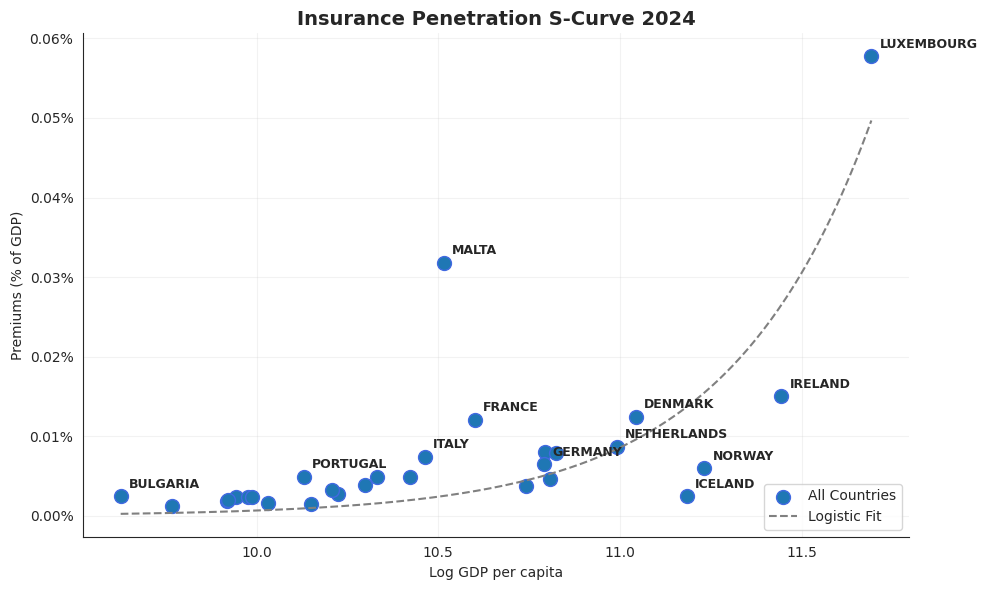

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd
from matplotlib.ticker import FuncFormatter

# Define the list of countries whose names you want to annotate
selected_countries = ['FRANCE', 'GERMANY', 'ITALY', 'LUXEMBOURG', 'MALTA', 'IRELAND', 'ICELAND','BULGARIA','PORTUGAL','NORWAY','DENMARK','NETHERLANDS']

# 1. Logistic function
def logistic(x, L, k, x0):
    return L / (1 + np.exp(-k * (x - x0)))

# Create log_GDP_per_capita directly in df_plot
df_plot['log_GDP_per_capita'] = np.log(df_plot['GDP per capita'])

# 2. Data: Use ALL countries for fitting and plotting
x = df_plot['log_GDP_per_capita']
y = df_plot['Percentaje of GDP'] * 100  # Convert to percentage

# 3. Fit logistic curve (using ALL data)
p0 = [max(y), 1, np.median(x)]  # initial guess
# Increased maxfev to avoid common "Optimal parameters not found" warnings
params, _ = curve_fit(logistic, x, y, p0=p0, maxfev=10000)
L, k, x0 = params

# 4. Generate smooth curve
x_range = np.linspace(x.min(), x.max(), 300)
y_curve = logistic(x_range, L, k, x0)


# 5. Plot
plt.figure(figsize=(10,6))
# Plot ALL countries' data points with no fill (just black outline)
plt.scatter(x, y, s=100, edgecolors='royalblue', label="All Countries")
# Logistic fit: grey, dashed, thinner
plt.plot(x_range, y_curve, linewidth=1.5, color='grey', linestyle='--', label="Logistic Fit")

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# 6. Conditional Annotation
# Iterate through ALL countries, but only annotate selected ones
for i, row in df_plot.iterrows():
    country = row['Reporting country']
    if country in selected_countries:
        plt.annotate(country,
                     (row['log_GDP_per_capita'], row['Percentaje of GDP']*100),
                     textcoords="offset points",
                     xytext=(6, 6),
                     fontsize=9,
                     fontweight='bold') # Added bolding for visibility

# 7. Y-Axis Percentage Formatting
def percentage_formatter(x, pos):
    """Formats the tick value x as a percentage string."""
    return f'{x:.2f}%'

formatter = FuncFormatter(percentage_formatter)
plt.gca().yaxis.set_major_formatter(formatter)

# Set labels and title
plt.xlabel("Log GDP per capita")
plt.ylabel("Premiums (% of GDP)")
plt.title("Insurance Penetration S-Curve 2024", fontsize=14, fontweight='bold')
plt.grid(alpha=0.25)
plt.legend(loc='lower right')
plt.tight_layout()


# How do the levels of insurers’ assets and liabilities correlate with country-level premiums written and claims incurred across EU insurance markets?


### Code for figures

In [ ]:
Life_B=Balance_Sheet_Original[Balance_Sheet_Original['Undertaking type']=='Life undertakings'].copy()
NonLife_B=Balance_Sheet_Original[Balance_Sheet_Original['Undertaking type']=='Non-Life undertakings'].copy()
Life_B=Life_B[['Reporting country','Date', 'Value','Item code']]
NonLife_B=NonLife_B[['Reporting country','Date', 'Value','Item code']]

Life_B = (
    Life_B.pivot_table(
        index=['Reporting country', 'Date'],
        columns='Item code',
        values='Value',
        aggfunc='sum',           # ✅ sum duplicates
        fill_value=0             # optional: replace NaNs with 0
    )
    .reset_index()
)
NonLife_B = (
    NonLife_B.pivot_table(
        index=['Reporting country', 'Date'],
        columns='Item code',
        values='Value',
        aggfunc='sum',           # ✅ sum duplicates
        fill_value=0             # optional: replace NaNs with 0
    )
    .reset_index()
)

In [ ]:
Life_B=Life_B[['Reporting country','Date','R0500_BS','R0900_BS']]
NonLife_B=NonLife_B[['Reporting country','Date','R0500_BS','R0900_BS']]
Life_B = Life_B.rename(columns={'R0500_BS': 'R0500_BS_L', 'R0900_BS': 'R0900_BS_L'})
NonLife_B = NonLife_B.rename(columns={'R0500_BS': 'R0500_BS_NL', 'R0900_BS': 'R0900_BS_NL'})
RQ3=df[['Reporting country','Date','R0500_BS','R0900_BS', 'R0110_P', 'R1410_P','R0310_P','R1610_P']].copy()
RQ3 = RQ3.merge(Life_B, on=["Reporting country", "Date"], how="outer")
RQ3 = RQ3.merge(NonLife_B, on=["Reporting country", "Date"], how="outer")

 General Correlation Matrix

In [ ]:
from datetime import date
RQ3_General=RQ3.copy()
RQ3_General['Premiums']=RQ3_General['R0110_P']+RQ3_General['R1410_P']
RQ3_General['Claims']=RQ3_General['R0310_P']+RQ3_General['R1610_P']
RQ3_General.drop(columns=['R0110_P', 'R1410_P','R0310_P','R1610_P','R0500_BS_L','R0900_BS_L','R0500_BS_NL','R0900_BS_NL'], inplace=True)
RQ3_General = RQ3_General.rename(columns={'R0500_BS': 'Assets', 'R0900_BS': 'Liabilities'})

num_cols = RQ3_General.select_dtypes(include='number').columns
RQ3_General[num_cols] = RQ3_General[num_cols] * 1000

df_numeric = RQ3_General.select_dtypes(include=['number'])
correlation_matrix = df_numeric.corr(method='pearson')

## Figure 2

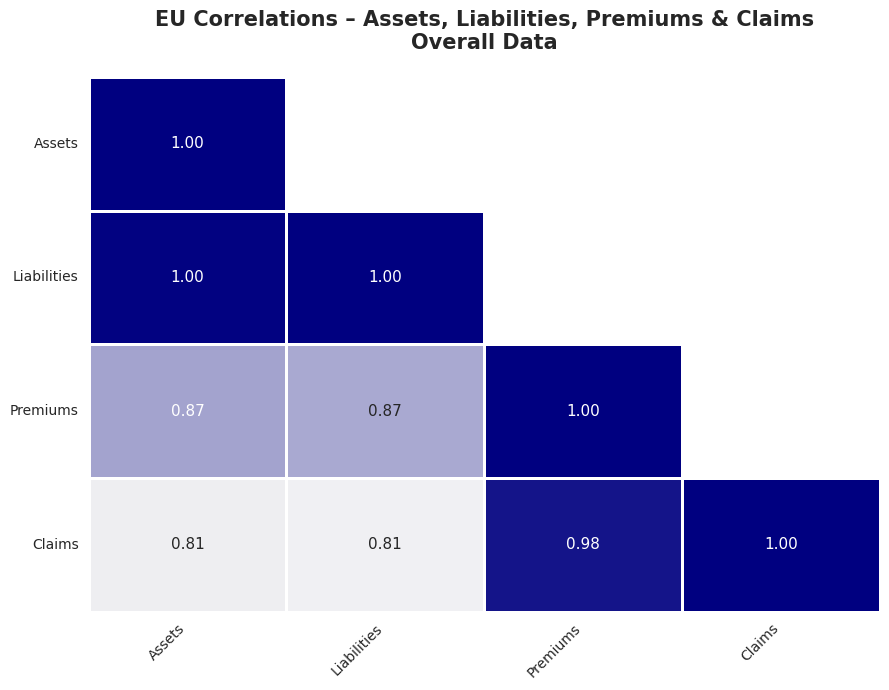

In [ ]:
import numpy as np

# Mask only the upper triangle (keep diagonal)
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool), k=1)

plt.figure(figsize=(9, 7))
sns.set_style("white")

ax = sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    cmap=sns.light_palette("navy", as_cmap=True),
    fmt=".2f",
    linewidths=0.8,
    cbar=False,
    annot_kws={"size": 11}
)

plt.title(
    'EU Correlations – Assets, Liabilities, Premiums & Claims\nOverall Data',
    fontsize=15,
    fontweight='bold',
    pad=20
)

# Keep ticks (variable names), remove axis *titles*
ax.set_xlabel("")   # removes the x-axis title ("Item code")
ax.set_ylabel("")   # removes the y-axis title ("Item code")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

sns.despine(left=True, bottom=True)
plt.tight_layout()


Life corr matrix

In [ ]:
RQ3_life=RQ3.copy()
RQ3_life['Premiums']=RQ3_life['R1410_P']
RQ3_life['Claims']=RQ3_life['R1610_P']
RQ3_life.drop(columns=['R0110_P', 'R1410_P','R0310_P','R1610_P','R0500_BS','R0900_BS','R0500_BS_NL','R0900_BS_NL'], inplace=True)
RQ3_life = RQ3_life.rename(columns={'R0500_BS_L': 'Assets', 'R0900_BS_L': 'Liabilities'})

num_cols = RQ3_life.select_dtypes(include='number').columns
RQ3_life[num_cols] = RQ3_life[num_cols] * 1000

df_numeric = RQ3_life.select_dtypes(include=['number'])
correlation_matrix = df_numeric.corr(method='pearson')

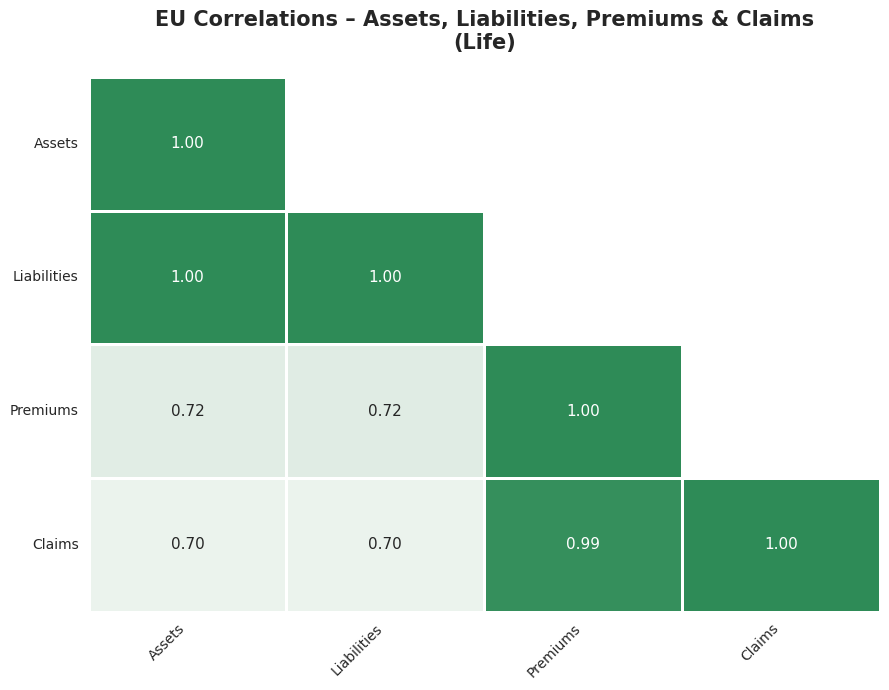

In [ ]:
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool), k=1)

plt.figure(figsize=(9, 7))
sns.set_style("white")

ax = sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    cmap=sns.light_palette("seagreen", as_cmap=True),
    fmt=".2f",
    linewidths=0.8,
    cbar=False,
    annot_kws={"size": 11}
)

plt.title(
    'EU Correlations – Assets, Liabilities, Premiums & Claims\n(Life)',
    fontsize=15,
    fontweight='bold',
    pad=20
)

# Keep ticks (variable names), remove axis *titles*
ax.set_xlabel("")   # removes the x-axis title ("Item code")
ax.set_ylabel("")   # removes the y-axis title ("Item code")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

sns.despine(left=True, bottom=True)
plt.tight_layout()

Non Life

In [ ]:
RQ3_nonlife=RQ3.copy()
RQ3_nonlife['Premiums']=RQ3_nonlife['R1410_P']
RQ3_nonlife['Claims']=RQ3_nonlife['R1610_P']
RQ3_nonlife.drop(columns=['R0110_P', 'R1410_P','R0310_P','R1610_P','R0500_BS','R0900_BS','R0500_BS_L','R0900_BS_L'], inplace=True)
RQ3_nonlife = RQ3_nonlife.rename(columns={'R0500_BS_NL': 'Assets', 'R0900_BS_NL': 'Liabilities'})

num_cols = RQ3_nonlife.select_dtypes(include='number').columns
RQ3_nonlife[num_cols] = RQ3_nonlife[num_cols] * 1000

df_numeric = RQ3_nonlife.select_dtypes(include=['number'])
correlation_matrix = df_numeric.corr(method='pearson')

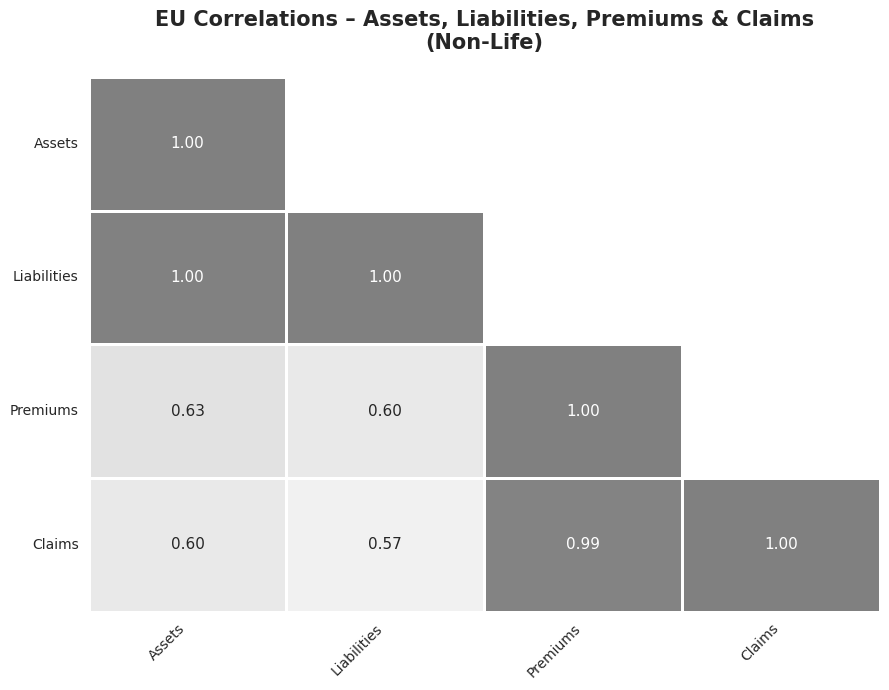

In [ ]:
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool), k=1)

plt.figure(figsize=(9, 7))
sns.set_style("white")

ax = sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    cmap=sns.light_palette("grey", as_cmap=True),
    fmt=".2f",
    linewidths=0.8,
    cbar=False,
    annot_kws={"size": 11}
)

plt.title(
    'EU Correlations – Assets, Liabilities, Premiums & Claims\n(Non-Life)',
    fontsize=15,
    fontweight='bold',
    pad=20
)

# Keep ticks (variable names), remove axis *titles*
ax.set_xlabel("")   # removes the x-axis title ("Item code")
ax.set_ylabel("")   # removes the y-axis title ("Item code")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

sns.despine(left=True, bottom=True)
plt.tight_layout()

## Figure 3

In [ ]:
df_corr = RQ3_General.copy()
df_corr = df_corr[df_corr['Date'].dt.quarter == 4].copy()
df_corr['Year'] = df_corr['Date'].dt.year
# Filter out rows where any of the key numeric columns are 0 or NaN
numeric_cols = ['Assets', 'Liabilities', 'Premiums', 'Claims']
df_corr = df_corr.dropna(subset=numeric_cols)  # remove NaNs
df_corr = df_corr[(df_corr[numeric_cols] != 0).all(axis=1)]  # remove zeros
latest_year = df_corr['Year'].max()
df_latest_year =df_corr

In [ ]:
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

countries = df_latest_year['Reporting country'].unique()
key_variables = ['Assets', 'Liabilities', 'Premiums', 'Claims']
n = len(key_variables)

fig = make_subplots(
    rows=n, cols=n,
    shared_xaxes=True,
    shared_yaxes=True,
    horizontal_spacing=0.02,
    vertical_spacing=0.02
)

# Choose a color palette
palette = px.colors.qualitative.Set2   # ← change this to any palette you want



# Assign a color per country
color_map = {country: palette[i % len(palette)] for i, country in enumerate(countries)}

# Add scatter plots only for diagonal and lower triangle
for i in range(n):
    for j in range(i+1):
        fig.add_trace(
            go.Scatter(
                x=df_latest_year[key_variables[j]],
                y=df_latest_year[key_variables[i]],
                mode='markers',
                marker=dict(color=[color_map[c] for c in df_latest_year['Reporting country']]),
                text=df_latest_year['Reporting country'] + " | Year: " + df_latest_year['Year'].astype(str),
                hoverinfo='text'
            ),
            row=i+1, col=j+1
        )

for idx, var in enumerate(key_variables):
    fig.update_xaxes(title_text=var, row=n, col=idx+1)
    fig.update_yaxes(title_text=var, row=idx+1, col=1)

fig.update_layout(
    height=800,
    width=800,
    title={
        'text': "<b>EU Scatter Matrix<br>(Overall)</b>",
        'x': 0.5,
        'xanchor': 'center'
    },
    showlegend=False
)


fig.show()


In [ ]:
RQ3_life

Item code,Reporting country,Date,Assets,Liabilities,Premiums,Claims
0,AUSTRIA,2016-07-01,1.611953e+07,1.527880e+07,0.0,0.0
1,AUSTRIA,2016-10-01,1.107098e+07,1.032562e+07,0.0,0.0
2,AUSTRIA,2017-01-01,1.097976e+07,1.020597e+07,0.0,0.0
3,AUSTRIA,2017-04-01,1.088179e+07,1.006920e+07,0.0,0.0
4,AUSTRIA,2017-07-01,1.088597e+07,1.005566e+07,0.0,0.0
...,...,...,...,...,...,...
1074,SWEDEN,2024-04-01,1.138877e+08,1.086002e+08,17130130.0,10301510.0
1075,SWEDEN,2024-07-01,1.184201e+08,1.129685e+08,25125140.0,15389330.0
1076,SWEDEN,2024-10-01,9.568230e+07,9.056264e+07,28868730.0,18799490.0
1077,SWEDEN,2025-01-01,1.205697e+08,1.151186e+08,11064280.0,5767920.0


In [ ]:
df_corr=RQ3_life.copy()
df_corr = df_corr[df_corr['Date'].dt.quarter == 4].copy()
df_corr['Year'] = df_corr['Date'].dt.year
# Filter out rows where any of the key numeric columns are 0 or NaN
numeric_cols = ['Assets', 'Liabilities', 'Premiums', 'Claims']
df_corr = df_corr.dropna(subset=numeric_cols)  # remove NaNs
df_corr = df_corr[(df_corr[numeric_cols] != 0).all(axis=1)]  # remove zeros
latest_year = df_corr['Year'].max()
df_latest_year =df_corr
print(f"DataFrame filtered for the latest year: {latest_year}")
df_latest_year.head()

import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

countries = df_latest_year['Reporting country'].unique()
key_variables = ['Assets', 'Liabilities', 'Premiums', 'Claims']
n = len(key_variables)

fig = make_subplots(
    rows=n, cols=n,
    shared_xaxes=True,
    shared_yaxes=True,
    horizontal_spacing=0.02,
    vertical_spacing=0.02
)

# Choose a color palette
palette = px.colors.sequential.Greens[4::2] # ← change this to any palette you want



# Assign a color per country
color_map = {country: palette[i % len(palette)] for i, country in enumerate(countries)}

# Add scatter plots only for diagonal and lower triangle
for i in range(n):
    for j in range(i+1):
        fig.add_trace(
            go.Scatter(
                x=df_latest_year[key_variables[j]],
                y=df_latest_year[key_variables[i]],
                mode='markers',
                marker=dict(color=[color_map[c] for c in df_latest_year['Reporting country']]),
                text=df_latest_year['Reporting country'] + " | Year: " + df_latest_year['Year'].astype(str),
                hoverinfo='text'
            ),
            row=i+1, col=j+1
        )

for idx, var in enumerate(key_variables):
    fig.update_xaxes(title_text=var, row=n, col=idx+1)
    fig.update_yaxes(title_text=var, row=idx+1, col=1)

fig.update_layout(
    height=800,
    width=800,
    title={
        'text': "<b>EU Scatter Matrix<br>(Life)</b>",
        'x': 0.5,
        'xanchor': 'center'
    },
    showlegend=False
)


fig.show()

DataFrame filtered for the latest year: 2024


In [ ]:
df_corr=RQ3_nonlife.copy()
df_corr = df_corr[df_corr['Date'].dt.quarter == 4].copy()
df_corr['Year'] = df_corr['Date'].dt.year
# Filter out rows where any of the key numeric columns are 0 or NaN
numeric_cols = ['Assets', 'Liabilities', 'Premiums', 'Claims']
df_corr = df_corr.dropna(subset=numeric_cols)  # remove NaNs
df_corr = df_corr[(df_corr[numeric_cols] != 0).all(axis=1)]  # remove zeros
latest_year = df_corr['Year'].max()
df_latest_year =df_corr
print(f"DataFrame filtered for the latest year: {latest_year}")
df_latest_year.head()

import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

countries = df_latest_year['Reporting country'].unique()
key_variables = ['Assets', 'Liabilities', 'Premiums', 'Claims']
n = len(key_variables)

fig = make_subplots(
    rows=n, cols=n,
    shared_xaxes=True,
    shared_yaxes=True,
    horizontal_spacing=0.02,
    vertical_spacing=0.02
)

# Choose a color palette
palette = px.colors.sequential.Greys[2::2]  # ← change this to any palette you want



# Assign a color per country
color_map = {country: palette[i % len(palette)] for i, country in enumerate(countries)}

# Add scatter plots only for diagonal and lower triangle
for i in range(n):
    for j in range(i+1):
        fig.add_trace(
            go.Scatter(
                x=df_latest_year[key_variables[j]],
                y=df_latest_year[key_variables[i]],
                mode='markers',
                marker=dict(color=[color_map[c] for c in df_latest_year['Reporting country']]),
                text=df_latest_year['Reporting country'] + " | Year: " + df_latest_year['Year'].astype(str),
                hoverinfo='text'
            ),
            row=i+1, col=j+1
        )

for idx, var in enumerate(key_variables):
    fig.update_xaxes(title_text=var, row=n, col=idx+1)
    fig.update_yaxes(title_text=var, row=idx+1, col=1)

fig.update_layout(
    height=800,
    width=800,
    title={
        'text': "<b>EU Scatter Matrix<br>(Non-Life)</b>",
        'x': 0.5,
        'xanchor': 'center'
    },
    showlegend=False
)


fig.show()

DataFrame filtered for the latest year: 2024
